In [10]:
import pandas as pd
import numpy as np

In [5]:
df =  pd.read_csv("C:/Users/hp/OneDrive/Desktop/WiDS/linear_regression_dataset.csv")

In [7]:
df.describe()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.054710,0.008010,-0.038337,0.047622,-0.001038,0.173609,0.099601,0.016408,0.025260,-0.077348,-0.059103,0.069801,0.095290
std,0.918381,1.036925,0.974231,1.037592,0.981510,1.006196,1.012267,1.022290,0.968789,0.993187,1.011703,1.002006,4.044871
min,-2.635748,-2.603137,-2.619745,-2.940389,-2.747505,-2.848543,-2.562334,-2.991136,-3.019512,-2.896255,-3.241267,-2.591042,-11.084768
25%,-0.544848,-0.677138,-0.707821,-0.575378,-0.669440,-0.437441,-0.552967,-0.752086,-0.626422,-0.774334,-0.758693,-0.660736,-2.654462
50%,0.146843,-0.089719,-0.020389,0.080009,-0.017365,0.203010,0.050906,0.033847,0.074243,-0.070899,-0.075938,-0.037396,-0.006583
75%,0.626633,0.699231,0.543510,0.733889,0.658720,0.859781,0.803336,0.682532,0.679054,0.564106,0.616143,0.755920,2.838709
max,2.426716,3.137749,2.644343,3.926238,2.526932,3.852731,2.620793,3.193108,2.412615,2.579709,3.078881,2.720169,13.787322


In [8]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      300 non-null    float64
 1   x2      300 non-null    float64
 2   x3      300 non-null    float64
 3   x4      300 non-null    float64
 4   x5      300 non-null    float64
 5   x6      300 non-null    float64
 6   x7      300 non-null    float64
 7   x8      300 non-null    float64
 8   x9      300 non-null    float64
 9   x10     300 non-null    float64
 10  x11     300 non-null    float64
 11  x12     300 non-null    float64
 12  y       300 non-null    float64
dtypes: float64(13)
memory usage: 30.6 KB


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.463418,-0.465730,-0.509170
1,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748,6.445471
2,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,-3.270552
3,0.208864,-1.959670,-1.328186,0.196861,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,1.964911
4,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,2.058044


Q7

In [14]:
X_WO_intercept = df.drop(columns=['y']).values
Y = df['y'].values.reshape(-1,1)

In [15]:
X = np.hstack([np.ones((X_WO_intercept.shape[0], 1)), X_WO_intercept])

In [17]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ Y

beta_hat_numpy = XtX_inv @ Xty
print("Beta (NumPy):\n", beta_hat_numpy)

Beta (NumPy):
 [[-0.07599727]
 [ 3.01921283]
 [-1.9986479 ]
 [ 0.46532073]
 [ 0.02874601]
 [ 0.97888014]
 [ 0.00519653]
 [ 0.05011683]
 [-0.9177461 ]
 [ 1.95197758]
 [-0.01228502]
 [ 0.05758946]
 [ 0.02741516]]


In [19]:
from sklearn.linear_model import LinearRegression

# Create model object
model = LinearRegression(fit_intercept=True)

# Fit the model
model.fit(X_WO_intercept, Y)

# Extract coefficients
beta_hat_sklearn = np.hstack([model.intercept_, model.coef_.flatten()])

print("Beta (sklearn):\n", beta_hat_sklearn)

Beta (sklearn):
 [-0.07599727  3.01921283 -1.9986479   0.46532073  0.02874601  0.97888014
  0.00519653  0.05011683 -0.9177461   1.95197758 -0.01228502  0.05758946
  0.02741516]


In [20]:
print("Beta from NumPy: ", beta_hat_numpy.flatten())
print("Beta from sklearn:", beta_hat_sklearn)

# Difference
print("\nDifference (NumPy - sklearn):")
print(beta_hat_numpy.flatten() - beta_hat_sklearn)

Beta from NumPy:  [-0.07599727  3.01921283 -1.9986479   0.46532073  0.02874601  0.97888014
  0.00519653  0.05011683 -0.9177461   1.95197758 -0.01228502  0.05758946
  0.02741516]
Beta from sklearn: [-0.07599727  3.01921283 -1.9986479   0.46532073  0.02874601  0.97888014
  0.00519653  0.05011683 -0.9177461   1.95197758 -0.01228502  0.05758946
  0.02741516]

Difference (NumPy - sklearn):
[ 1.11022302e-16  2.66453526e-15  1.11022302e-15 -1.11022302e-16
 -2.25514052e-16 -7.77156117e-16 -1.39818712e-15 -1.47798440e-15
 -7.77156117e-16 -4.44089210e-16 -9.02056208e-17 -3.74700271e-16
  6.45317133e-16]


Q8

In [21]:
# Fitted values
y_hat = X @ beta_hat_numpy   # shape (n,1)

# Residuals
residuals = Y - y_hat

In [22]:
y_hat_flat = y_hat.flatten()
residuals_flat = residuals.flatten()

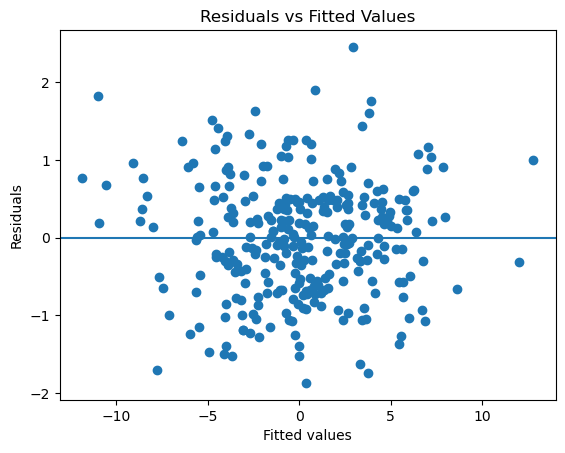

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_hat_flat, residuals_flat)
plt.axhline(y=0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The residuals versus fitted values plot shows a random scatter around zero with approximately constant variance across the range of fitted values. There is no strong evidence of heteroscedasticity, so the homoscedasticity assumption of the linear regression model appears to be satisfied.

Q9

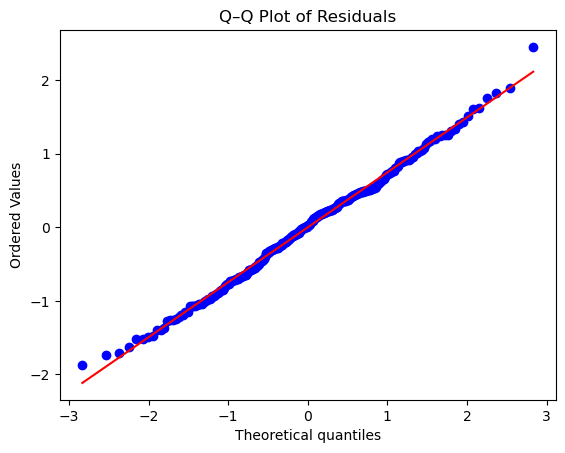

In [24]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure()
stats.probplot(residuals_flat, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q–Q plot shows that the residuals closely follow the reference line, with minor deviations at the tails. This suggests that the normality assumption of the residuals is reasonably satisfied.

Q11

In [25]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
H = X @ XtX_inv @ X.T

In [27]:
leverage = np.diag(H)

n, p_plus_1 = X.shape
leverage_threshold = 2 * p_plus_1 / n

high_leverage_points = np.where(leverage > leverage_threshold)[0]
print("High leverage points:", high_leverage_points)

High leverage points: [ 96 160 240]


In [28]:
# Residuals
residuals = (Y - X @ beta_hat_numpy).flatten()

# Mean squared error
MSE = np.mean(residuals**2)

# Cook's distance
cooks_d = (residuals**2 / ((p_plus_1) * MSE)) * (leverage / (1 - leverage)**2)

In [29]:
cooks_threshold = 4 / n
influential_points = np.where(cooks_d > cooks_threshold)[0]

print("Influential points:", influential_points)

Influential points: [ 18  59  86  88 116 117 121 129 146 155 178 267 282 286 293 296]


Leverage → “Is this x-value unusual?”

Cook’s distance → “Does this point change the model?”

The hat matrix was used to compute leverage values, identifying observations with unusually large influence in the predictor space. Several points exceeded the leverage threshold, indicating high leverage. Cook’s distance further identified influential observations whose removal would substantially affect the fitted model. Such points may disproportionately impact parameter estimates and should be examined for outliers, data errors, or model misspecification.